Archivos procesados. Se encontraron 40 espectros únicos:
'RamanFilmSamples_GDBand_514nm_Film T1 S-SWCNTs',
'RamanFilmSamples_GDBand_514nm_Film T1 S-SWCNTs Converted',
'RamanFilmSamples_GDBand_514nm_Film T2 S-SWCNTs',
'RamanFilmSamples_GDBand_514nm_Film T2 S-SWCNTs Converted',
'RamanFilmSamples_GDBand_514nm_Film T9 M-SWCNTs',
'RamanFilmSamples_GDBand_514nm_Film T9 M-SWCNTs Converted',
'RamanFilmSamples_GDBand_561nm_Film T1S (SWCNT)',
'RamanFilmSamples_GDBand_561nm_Film T1S (Converted to DWCNT)',
'RamanFilmSamples_GDBand_561nm_Film T2S (SWCNT)',
'RamanFilmSamples_GDBand_561nm_Film T2S (Converted to DWCNT)',
'RamanFilmSamples_GDBand_561nm_Film T9M (SWCNT)',
'RamanFilmSamples_GDBand_561nm_Film T9M (Converted to DWCNT)',
'RamanFilmSamples_RBM_514nm_Film T1 S-SWCNTs',
'RamanFilmSamples_RBM_514nm_Film T1 S-SWCNTs Converted',
'RamanFilmSamples_RBM_514nm_Film T2 S-SWCNTs',
'RamanFilmSamples_RBM_514nm_Film T2 S-SWCNTs Converted',
'RamanFilmSamples_RBM_514nm_Film T9 M-SWCNTs',
'RamanFilmSamples_R

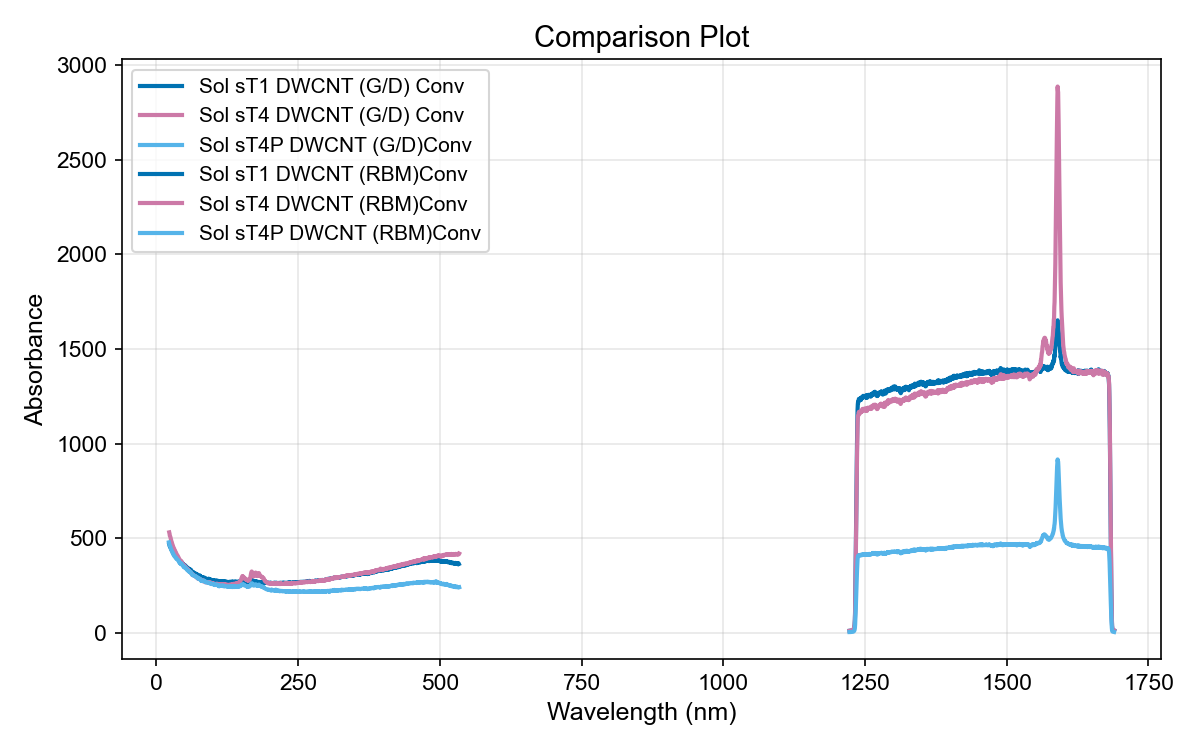

In [74]:
%matplotlib widget
import csv
import os
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from dataclasses import dataclass

# ============================================================
# 1. STYLE & OBJECT CONFIGURATION
# ============================================================
@dataclass
class Spectrum:
    N: str                  # Nombre o Label original
    X: np.ndarray           # X data
    Y: np.ndarray           # Y data
    color: str = None       # Color para ploteo
    linestyle: str = None   # Estilo de línea

    def copy(self):
        """Devuelve una copia profunda del espectro conservando sus propiedades"""
        return Spectrum(
            N=self.N, 
            X=self.X.copy(), 
            Y=self.Y.copy(), 
            color=self.color,         
            linestyle=self.linestyle  
        )

poster_style = {
    "figsize": (8, 5),          
    "dpi": 150,                 
    "font_size": 11,
    "title_size": 14,
    "label_size": 12,
    "legend_size": 10,
    "line_width": 2,
    "font_family": "Arial", # O "Calibri" si lo prefieres
    "grid": True,               
    "colors": ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00", "#F0E442"], 
    "linestyles": ["-", "--", "-.", ":"]
}

# ============================================================
# 2. CORE PLOTTING FUNCTION
# ============================================================
def PlotSpectra(spectra_list, style=poster_style, xlabel="X", ylabel="Y", title="Selected Spectra", 
                xmin=None, xmax=None, ymin=None, ymax=None, 
                offset_step=0.0, # <--- PARÁMETRO DE OFFSET AÑADIDO
                save_path=None):
    
    fig, ax = plt.subplots(figsize=style["figsize"], dpi=style["dpi"])
    plt.rcParams.update({"font.size": style["font_size"], "font.family": style["font_family"]})
    
    default_colors = style.get("colors") or ["#000000"]
    default_linestyles = style.get("linestyles") or ["-"]
    
    for i, s in enumerate(spectra_list):
        # Prioridad: Atributo del objeto -> Default del estilo
        c = getattr(s, 'color', None) or default_colors[i % len(default_colors)]
        ls = getattr(s, 'linestyle', None) or default_linestyles[i % len(default_linestyles)]
        
        # --- APLICAMOS EL OFFSET MATEMÁTICO AQUÍ ---
        # Multiplicamos el offset por el índice 'i' para que se apilen escalonadamente
        y_stacked = s.Y + (i * offset_step)
        
        ax.plot(s.X, y_stacked, label=s.N, linewidth=style["line_width"], color=c, linestyle=ls)

    ax.set_xlabel(xlabel, fontsize=style["label_size"])
    ax.set_ylabel(ylabel, fontsize=style["label_size"])
    ax.set_title(title, fontsize=style["title_size"])
    
    if xmin is not None or xmax is not None: ax.set_xlim(xmin, xmax)
    if ymin is not None or ymax is not None: ax.set_ylim(ymin, ymax)
    if style.get("grid", False): ax.grid(True, alpha=0.3)

    ax.legend(fontsize=style["legend_size"])
    fig.tight_layout()
    
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=style["dpi"], bbox_inches="tight")
        print(f"Saved: {save_path}")
        
    plt.show()

# ============================================================
# 3. DATA LOADING (CSV PARSER)
# ============================================================
def read_samples_to_spectra(filename):
    """Read repeated Name,X,Y blocks from one CSV file and return a list of Spectrum objects."""
    samples = {}
    with open(filename, "r", newline="", encoding="utf-8-sig") as f:
        reader = csv.reader(f)
        try:
            header = next(reader)
        except StopIteration:
            raise ValueError(f"Empty file: {filename}")

        if len(header) < 3 or len(header) % 3 != 0:
            raise ValueError(f"{filename}: number of columns ({len(header)}) must be a multiple of 3.")

        n_samples = len(header) // 3

        for row_number, row in enumerate(reader, start=2):
            if not row or all(not cell.strip() for cell in row):
                continue

            if len(row) < 3 * n_samples:
                row = row + [""] * (3 * n_samples - len(row))
            if len(row) > 3 * n_samples:
                raise ValueError(f"{filename}, row {row_number}: found {len(row)} columns; expected {3 * n_samples}.")

            for i in range(n_samples):
                name = row[3*i].strip()
                x_text = row[3*i + 1].strip()
                y_text = row[3*i + 2].strip()

                if not name or not x_text or not y_text:
                    continue

                try:
                    x = float(x_text)
                    y = float(y_text)
                except ValueError:
                    continue

                samples.setdefault(name, ([], []))
                samples[name][0].append(x)
                samples[name][1].append(y)

    spectra_list = []
    for name, (x_list, y_list) in samples.items():
        s = Spectrum(N=name, X=np.array(x_list), Y=np.array(y_list))
        spectra_list.append(s)
        
    return spectra_list

def load_all_spectra(folder_path, pattern="*.csv"):
    """Reads all CSVs and dumps EVERY spectrum into a single dictionary with unique keys."""
    folder = Path(folder_path)
    files = sorted(folder.glob(pattern))
    
    global_spectra_dict = {}
    for file in files:
        try:
            file_spectra = read_samples_to_spectra(file)
            for s in file_spectra:
                # --- CORRECCIÓN AQUÍ ---
                # Creamos una llave única combinando NombreArchivo_NombreMuestra
                unique_key = f"{file.stem}_{s.N}"
                global_spectra_dict[unique_key] = s 
        except Exception as e:
            print(f"Skipping {file.name}: {e}")
            
    return global_spectra_dict


def TrimSpectra(spectra_input, xmin=None, xmax=None):
    if not isinstance(spectra_input, list):
        spectra_input = [spectra_input]
    res = []
    for s in spectra_input:
        new_s = s.copy()
        mask = np.ones_like(new_s.X, dtype=bool)
        if xmin is not None: mask &= (new_s.X >= xmin)
        if xmax is not None: mask &= (new_s.X <= xmax)
        
        if not np.any(mask):
            print(f"Warning: empty trim range for {new_s.N}")
            continue
            
        new_s.X = new_s.X[mask]
        new_s.Y = new_s.Y[mask]
        res.append(new_s)
    return res

def NormalizeSpectra(spectra_list, xmin, xmax, mode="M"):
    """
    mode="M" (Maximum), "I" (Integration/Area), "V" (Minimum)
    """
    res = []
    for s in spectra_list:
        new_s = s.copy()
        # Encontrar datos dentro de la ventana
        mask = (new_s.X >= xmin) & (new_s.X <= xmax)
        X_win, Y_win = new_s.X[mask], new_s.Y[mask]
        
        if len(X_win) == 0: 
            print(f"Warning: No data in normalization window for {new_s.N}")
            continue
        
        if mode.upper() == "M": factor = np.max(Y_win)
        elif mode.upper() == "I": factor = np.trapezoid(Y_win, X_win)
        elif mode.upper() == "V": factor = np.min(Y_win)
        else: raise ValueError("Invalid mode")
        
        if factor != 0:
            new_s.Y = new_s.Y / factor
        res.append(new_s)
    return res

def SubtractMinimum(spectra_input, xmin=None, xmax=None):
    """
    Encuentra el mínimo en la región [xmin, xmax] y se lo resta a todo el espectro.
    Esto 'arrastra' el espectro hacia abajo para que el mínimo local sea exactamente cero.
    """
    is_single = isinstance(spectra_input, Spectrum)
    spectra_list = [spectra_input] if is_single else spectra_input
    
    res = []
    for s in spectra_list:
        new_s = s.copy()
        
        # Encontrar la ventana para buscar el mínimo
        mask = np.ones_like(new_s.X, dtype=bool)
        if xmin is not None: mask &= (new_s.X >= xmin)
        if xmax is not None: mask &= (new_s.X <= xmax)
        
        if not np.any(mask):
            print(f"Warning: Rango de búsqueda de mínimo vacío para {new_s.N}")
            res.append(new_s)
            continue
            
        # Buscar el valor Y más bajo en esa ventana y restarlo a todo el array
        min_val = np.min(new_s.Y[mask])
        new_s.Y = new_s.Y - min_val
        
        res.append(new_s)
        
    return res[0] if is_single else res

def SubtractLinearBackground(spectra_input, x1, x2):
    """
    Evalúa la intensidad en x1 y x2, traza una línea recta entre ellos 
    (y = mx + b) y la resta de todo el espectro para eliminar fondos inclinados.
    """
    is_single = isinstance(spectra_input, Spectrum)
    spectra_list = [spectra_input] if is_single else spectra_input
    
    res = []
    for s in spectra_list:
        new_s = s.copy()
        
        if x1 == x2:
            print(f"Warning: x1 y x2 son idénticos para {new_s.N}. No se aplicó baseline.")
            res.append(new_s)
            continue
            
        # Interpolar para asegurar que obtenemos el valor Y exacto en x1 y x2 
        # (incluso si el punto X exacto no existe en el array original)
        y1 = np.interp(x1, new_s.X, new_s.Y)
        y2 = np.interp(x2, new_s.X, new_s.Y)
        
        # Calcular pendiente (m) y punto de corte (b)
        m = (y2 - y1) / (x2 - x1)
        b = y1 - m * x1
        
        # Calcular la recta para todo el eje X y restarla
        line_y = m * new_s.X + b
        new_s.Y = new_s.Y - line_y
        
        res.append(new_s)
        
    return res[0] if is_single else res

# ============================================================
# 4. EXECUTION & SELECTION
# ============================================================
FOLDER_PATH = r"H:\UAntwerp\2. Paper on DWCNTs - Shivani KIT\Data\Raman"

# 1. Cargamos TODOS los espectros
spectra_dict = load_all_spectra(FOLDER_PATH, "*.csv")

print(f"Archivos procesados. Se encontraron {len(spectra_dict)} espectros únicos:")
for key in spectra_dict.keys():
    print("'"+f"{key}"+"',")

print("\n")

# 2. SELECCIÓN MAESTRA
# Ahora usarás la llave combinada que se imprimió arriba
spectra_config = [
    
    # =========================================================
    # A. S O L U T I O N   S A M P L E S 
    # =========================================================
    
    # --- 514 nm | G/D Band --- NO VALE LA PENA
     ('RamanSolutionSamples_GDBand_514nm_Sol. T1 S-SWCNTs Converted',   'Sol sT1 DWCNT (G/D) Conv',  '#0072B2', '-'),
     ('RamanSolutionSamples_GDBand_514nm_Sol.T4 S-SWCNTs Converted',    'Sol sT4 DWCNT (G/D) Conv',  '#CC79A7', '-'),
     ('RamanSolutionSamples_GDBand_514nm_Sol.T4P S-SWCNTs Converted',   'Sol sT4P DWCNT (G/D)Conv', '#56B4E9', '-'),
    
    # --- 514 nm | RBM ---
     ('RamanSolutionSamples_RBM_514nm_Sol.T1 S-SWCNTs Converted',       'Sol sT1 DWCNT (RBM)Conv',  '#0072B2', '-'),
     ('RamanSolutionSamples_RBM_514nm_Sol.T4 S-SWCNTs Converted',       'Sol sT4 DWCNT (RBM)Conv',  '#CC79A7', '-'),
     ('RamanSolutionSamples_RBM_514nm_Sol.T4P S-SWCNTs Converted',      'Sol sT4P DWCNT (RBM)Conv', '#56B4E9', '-'),

]


Selection = []
for key, name, col, ls in spectra_config:
    if key in spectra_dict:
        s = spectra_dict[key].copy()
        s.N = name
        s.color = col
        s.linestyle = ls
        Selection.append(s)
    else:
        print(f"Advertencia: El espectro '{key}' no existe.")

#Selection = TrimSpectra(Selection, xmin=1240, xmax=1650)
#Selection = SubtractLinearBackground(Selection, 1300, 1600)
#Selection = NormalizeSpectra(Selection, 1300, 1600)

# 3. GRAFICAR
if len(Selection) > 0:
    PlotSpectra(
        spectra_list=Selection,
        style=poster_style,
        xlabel="Wavelength (nm)",  # Ajusta tus labels
        ylabel="Absorbance",
        title="Comparison Plot",
    )

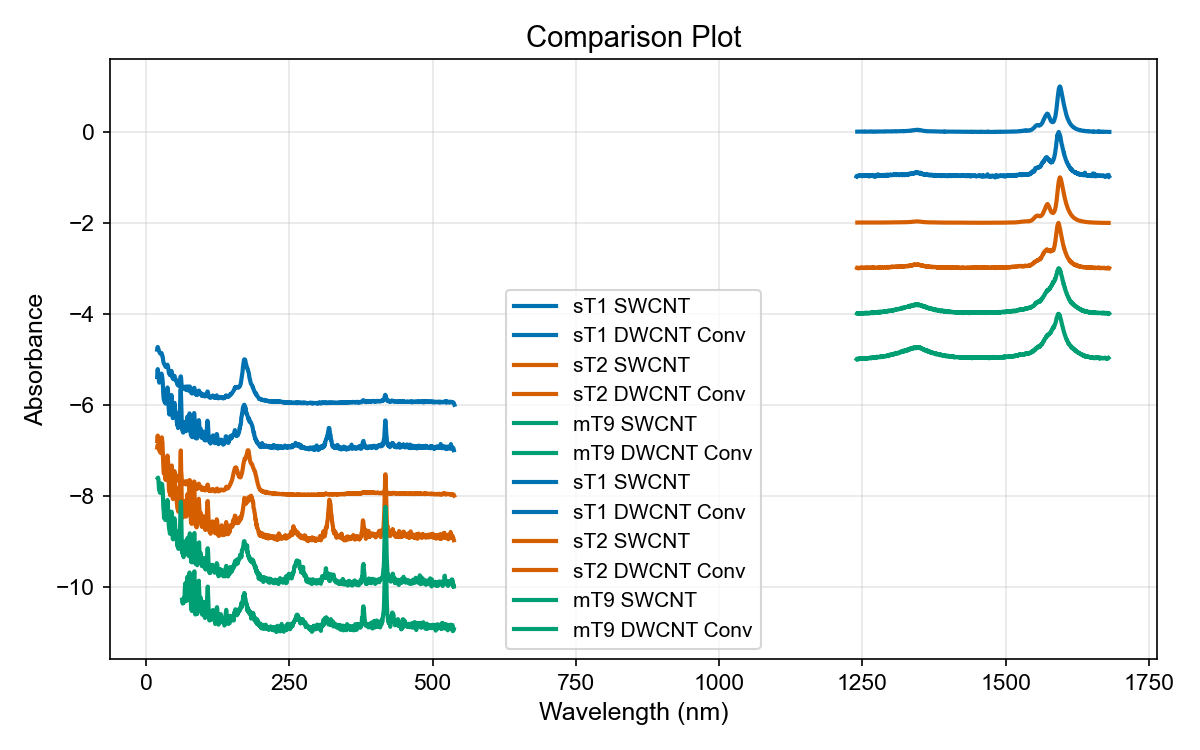

In [75]:
spectra_config = [
    
    # =========================================================
    # B. F I L M   S A M P L E S 
    # =========================================================

    # ---------------------------------------------------------
    # B.1 Láser: 514 nm ------ TAL VEZ VALE LA PENA
    # ---------------------------------------------------------
    
    # --- 514 nm | G/D Band ---
    ('RamanFilmSamples_GDBand_514nm_Film T1 S-SWCNTs',                 'sT1 SWCNT',    '#0072B2', '-'),
    ('RamanFilmSamples_GDBand_514nm_Film T1 S-SWCNTs Converted',       'sT1 DWCNT Conv',    '#0072B2', '-'),
    ('RamanFilmSamples_GDBand_514nm_Film T2 S-SWCNTs',                 'sT2 SWCNT',    '#D55E00', '-'),
    ('RamanFilmSamples_GDBand_514nm_Film T2 S-SWCNTs Converted',       'sT2 DWCNT Conv',    '#D55E00', '-'),
    ('RamanFilmSamples_GDBand_514nm_Film T9 M-SWCNTs',                 'mT9 SWCNT',    '#009E73', '-'),
    ('RamanFilmSamples_GDBand_514nm_Film T9 M-SWCNTs Converted',       'mT9 DWCNT Conv',    '#009E73', '-'),

    # --- 514 nm | RBM --------- TAL VEZ VALE LA PENA
    ('RamanFilmSamples_RBM_514nm_Film T1 S-SWCNTs',                    'sT1 SWCNT',    '#0072B2', '-'),
    ('RamanFilmSamples_RBM_514nm_Film T1 S-SWCNTs Converted',          'sT1 DWCNT Conv',    '#0072B2', '-'),
    ('RamanFilmSamples_RBM_514nm_Film T2 S-SWCNTs',                    'sT2 SWCNT',    '#D55E00', '-'),
    ('RamanFilmSamples_RBM_514nm_Film T2 S-SWCNTs Converted',          'sT2 DWCNT Conv',    '#D55E00', '-'),
    ('RamanFilmSamples_RBM_514nm_Film T9 M-SWCNTs',                    'mT9 SWCNT',    '#009E73', '-'),
    ('RamanFilmSamples_RBM_514nm_Film T9 M-SWCNTs Converted',          'mT9 DWCNT Conv',    '#009E73', '-'),



]


Selection = []
for key, name, col, ls in spectra_config:
    if key in spectra_dict:
        s = spectra_dict[key].copy()
        s.N = name
        s.color = col
        s.linestyle = ls
        Selection.append(s)
    else:
        print(f"Advertencia: El espectro '{key}' no existe.")

#Selection = TrimSpectra(Selection, xmin=1240, xmax=1650)
#Selection = SubtractLinearBackground(Selection, 1300, 1600)
#Selection = NormalizeSpectra(Selection, 1300, 1600)

# 3. GRAFICAR
if len(Selection) > 0:
    PlotSpectra(
        spectra_list=Selection,
        style=poster_style,
        xlabel="Wavelength (nm)",  # Ajusta tus labels
        ylabel="Absorbance",
        title="Comparison Plot",
        offset_step=-1  
    )

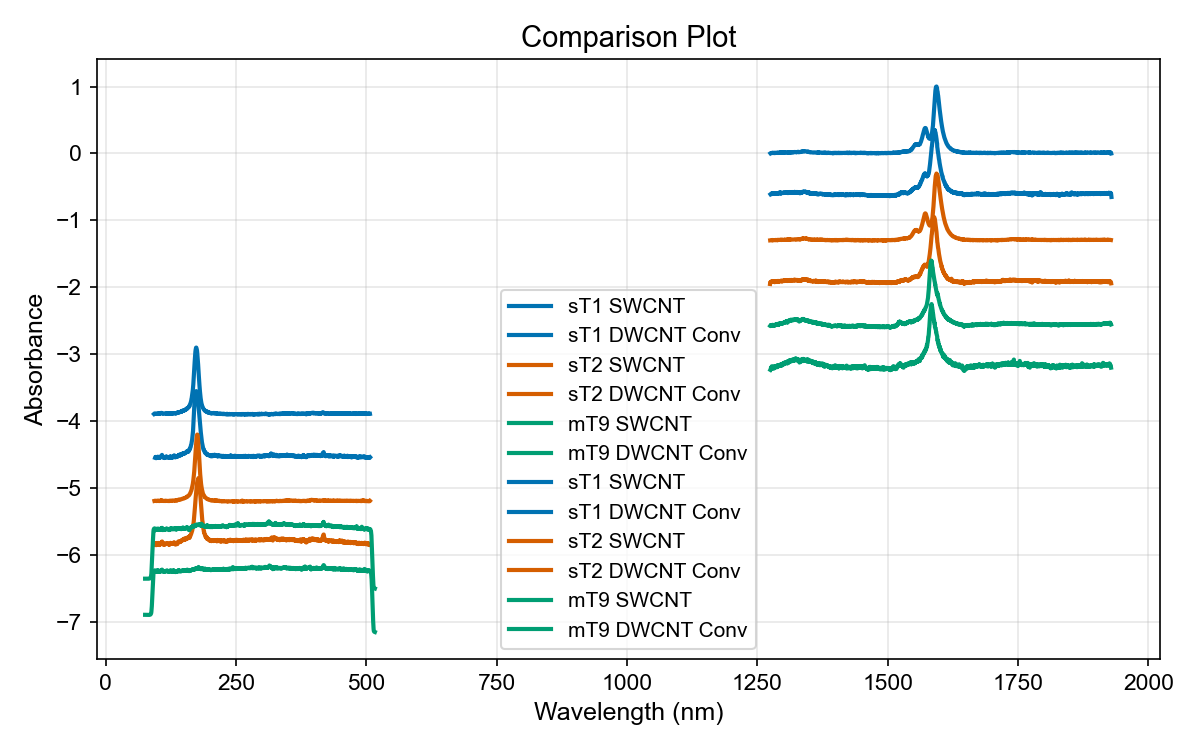

In [76]:
spectra_config = [

    # ---------------------------------------------------------
    # B.2 Láser: 561 nm
    # ---------------------------------------------------------

    # --- 561 nm | G/D Band ---
     ('RamanFilmSamples_GDBand_561nm_Film T1S (SWCNT)',                 'sT1 SWCNT',    '#0072B2', '-'),
     ('RamanFilmSamples_GDBand_561nm_Film T1S (Converted to DWCNT)',    'sT1 DWCNT Conv',    '#0072B2', '-'),
     ('RamanFilmSamples_GDBand_561nm_Film T2S (SWCNT)',                 'sT2 SWCNT',    '#D55E00', '-'),
     ('RamanFilmSamples_GDBand_561nm_Film T2S (Converted to DWCNT)',    'sT2 DWCNT Conv',    '#D55E00', '-'),
     ('RamanFilmSamples_GDBand_561nm_Film T9M (SWCNT)',                 'mT9 SWCNT',    '#009E73', '-'),
     ('RamanFilmSamples_GDBand_561nm_Film T9M (Converted to DWCNT)',    'mT9 DWCNT Conv',    '#009E73', '-'),

    # --- 561 nm | RBM --- NO SE SI VALGA LA PENA
     ('RamanSemicondFilmSamples_RBM_561nm_Film T1 S-SWCNTs',            'sT1 SWCNT',    '#0072B2', '-'),
     ('RamanSemicondFilmSamples_RBM_561nm_Film T1 S-SWCNTs Converted',  'sT1 DWCNT Conv',    '#0072B2', '-'),
     ('RamanSemicondFilmSamples_RBM_561nm_Film T2 S-SWCNTs',            'sT2 SWCNT',    '#D55E00', '-'),
     ('RamanSemicondFilmSamples_RBM_561nm_Film T2 S-SWCNTs Converted',  'sT2 DWCNT Conv',    '#D55E00', '-'),
     ('RamanMetallicFilmSamples_RBM_561nm_Film T9 M-SWCNTs',            'mT9 SWCNT',    '#009E73', '-'),
     ('RamanMetallicFilmSamples_RBM_561nm_Film T9 M-SWCNTs Converted',  'mT9 DWCNT Conv',    '#009E73', '-'),


]


Selection = []
for key, name, col, ls in spectra_config:
    if key in spectra_dict:
        s = spectra_dict[key].copy()
        s.N = name
        s.color = col
        s.linestyle = ls
        Selection.append(s)
    else:
        print(f"Advertencia: El espectro '{key}' no existe.")

#Selection = TrimSpectra(Selection, xmin=1240, xmax=1650)
#Selection = SubtractLinearBackground(Selection, 1300, 1600)
#Selection = NormalizeSpectra(Selection, 1300, 1600)

# 3. GRAFICAR
if len(Selection) > 0:
    PlotSpectra(
        spectra_list=Selection,
        style=poster_style,
        xlabel="Wavelength (nm)",  # Ajusta tus labels
        ylabel="Absorbance",
        title="Comparison Plot",
        offset_step=-0.65  
    )

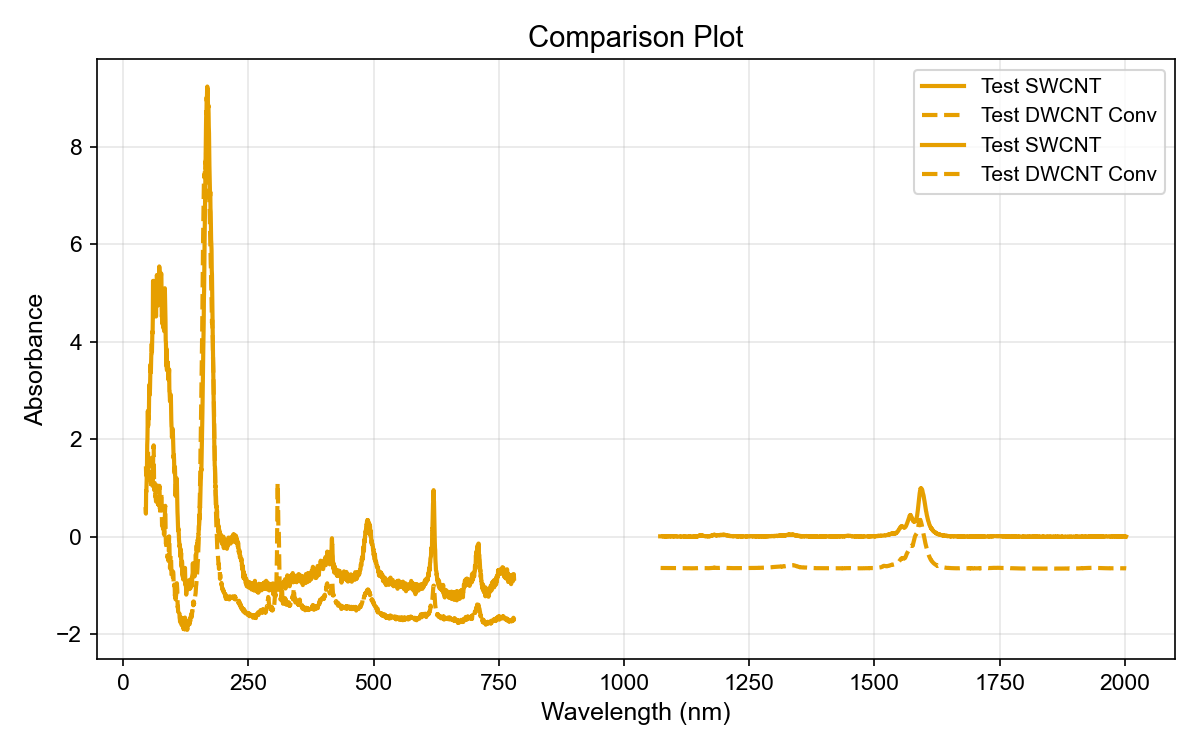

In [77]:
spectra_config = [
    # ---------------------------------------------------------
    # B.3 Láser: 570 nm (Test Samples) ---- VERY GOOD
    # ---------------------------------------------------------

    # --- 570 nm | G/D Band ---
     ('RamanTestSamples_GDBand_570nm_Test Film Sample (SWCNT)',               'Test SWCNT',  '#E69F00', '-'),
     ('RamanTestSamples_GDBand_570nm_Test Film Sample (Converted to DWCNT)',  'Test DWCNT Conv',  '#E69F00', '--'),

    # --- 570 nm | RBM ---
     ('RamanTestSamples_RBM_570nm_Test Film Sample (SWCNT)',                  'Test SWCNT',  '#E69F00', '-'),
     ('RamanTestSamples_RBM_570nm_Test Film Sample (Converted to DWCNT)',     'Test DWCNT Conv',  '#E69F00', '--'),
]


Selection = []
for key, name, col, ls in spectra_config:
    if key in spectra_dict:
        s = spectra_dict[key].copy()
        s.N = name
        s.color = col
        s.linestyle = ls
        Selection.append(s)
    else:
        print(f"Advertencia: El espectro '{key}' no existe.")

#Selection = TrimSpectra(Selection, xmin=1240, xmax=1650)
#Selection = SubtractLinearBackground(Selection, 1300, 1600)
#Selection = NormalizeSpectra(Selection, 1300, 1600)

# 3. GRAFICAR
if len(Selection) > 0:
    PlotSpectra(
        spectra_list=Selection,
        style=poster_style,
        xlabel="Wavelength (nm)",  # Ajusta tus labels
        ylabel="Absorbance",
        title="Comparison Plot",
        offset_step=-0.65  
    )

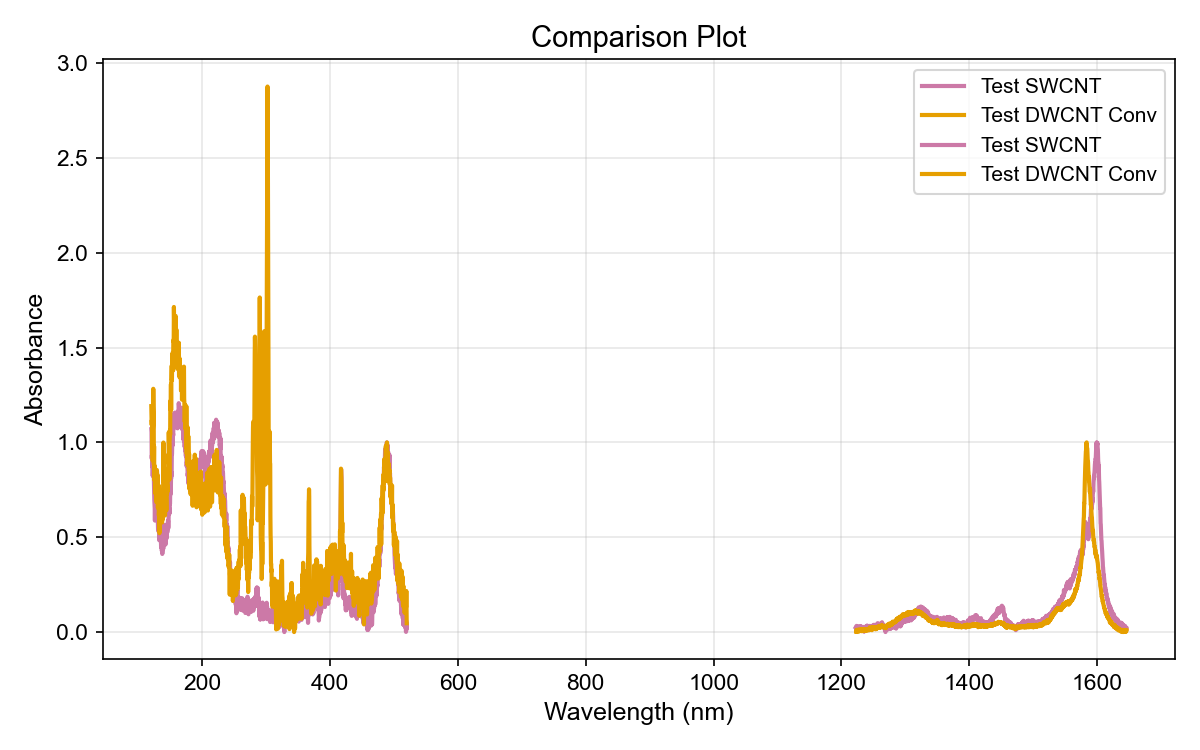

In [78]:
spectra_config = [

    # ---------------------------------------------------------
    # B.4 Láser: 650 nm (Test Samples)
    # ---------------------------------------------------------
    # --- 650 nm | RBM ---
     ('RamanTestSamples_RBM_650nm_Test Film Sample (SWCNT)',                  'Test SWCNT',  '#CC79A7', '-'),
     ('RamanTestSamples_RBM_650nm_Test Film Sample (Converted to DWCNT)',     'Test DWCNT Conv',  '#E69F00', '-'),
     
    # --- 650 nm | G/D Band ---
     ('RamanTestSamples_GDBand_650nm_Test Film Sample (SWCNT)',               'Test SWCNT',  '#CC79A7', '-'),
     ('RamanTestSamples_GDBand_650nm_Test Film Sample (Converted to DWCNT)',  'Test DWCNT Conv',  '#E69F00', '-'),

    # --- 650 nm | Carbyne Region --- REDUDANTE. MISMA G BAND
     #('RamanTestSamples_GBandCarbyneRegion_650nm_Test Film Sample (SWCNT)',               'Test SWCNT',  '#CC79A7', '-'),
     #('RamanTestSamples_GBandCarbyneRegion_650nm_Test Film Sample (Converted to DWCNT)',  'Test DWCNT Conv',  '#E69F00', '-'),



]


Selection = []
for key, name, col, ls in spectra_config:
    if key in spectra_dict:
        s = spectra_dict[key].copy()
        s.N = name
        s.color = col
        s.linestyle = ls
        Selection.append(s)
    else:
        print(f"Advertencia: El espectro '{key}' no existe.")

#Selection = TrimSpectra(Selection, xmin=1240, xmax=1650)
#Selection = SubtractLinearBackground(Selection, 1300, 1600)
#Selection = NormalizeSpectra(Selection, 1300, 1600)

# 3. GRAFICAR
if len(Selection) > 0:
    PlotSpectra(
        spectra_list=Selection,
        style=poster_style,
        xlabel="Wavelength (nm)",  # Ajusta tus labels
        ylabel="Absorbance",
        title="Comparison Plot",
        offset_step=-0.0  
    )